# TurboQuant Comparison: With vs Without
Compares TurboQuant (3-bit and 4-bit) against standard INT8/INT4 quantization and Stratigraphic zone-based compression on Llama-3.2-1B-Instruct (WikiText-2).

**TurboQuant** (Google, ICLR 2026): random rotation + optimal scalar quantization + QJL residual correction. Claims 3-bit KV cache with zero accuracy loss.

**Requires GPU** (A100 recommended, ~20-30 min for 6 strategies).

Strategies compared:
1. **FullKV** (FP16 baseline)
2. **INT8-all** — uniform symmetric 8-bit quantization (KIVI-style)
3. **INT4-all** — uniform symmetric 4-bit quantization
4. **TQ3-all** — TurboQuant 3-bit (2-bit scalar + 1-bit QJL)
5. **TQ4-all** — TurboQuant 4-bit (3-bit scalar + 1-bit QJL)
6. **Stratigraphic** — zone-based INT8/INT4 with importance scoring

In [1]:
import sys, os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if os.path.exists(os.path.join(project_root, 'kv_bench')):
    if project_root not in sys.path:
        sys.path.insert(0, project_root)
    os.chdir(project_root)
elif os.path.exists('PROJECT/kv_bench'):
    os.chdir('PROJECT')
    sys.path.insert(0, os.getcwd())
else:
    os.system('GIT_SSL_NO_VERIFY=1 git clone https://gitlab.cim.rhul.ac.uk/wmis066/PROJECT.git PROJECT')
    os.chdir('PROJECT')
    os.system('pip install -e .')
    sys.path.insert(0, os.getcwd())

print(f'Working dir: {os.getcwd()}')

import torch
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from kv_bench.runner import BenchmarkRunner
from kv_bench.device_config import auto_detect
from kv_bench.report import print_table, save_json
from kv_bench.strategies import (
    FullKVBaseline,
    UniformQuantStrategy,
    StratigraphicStrategy,
    TurboQuantStrategy,
)

print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name()}')

Cloning into 'PROJECT'...


Obtaining file:///root/PROJECT
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 107.1 MB/s eta 0:00:00


  DEPRECATION: Legacy editable install of streaming_attention==0.3.0 from file:///root/PROJECT (setup.py develop) is deprecated. pip 25.0 will enforce this behaviour change. A possible replacement is to add a pyproject.toml or enable --use-pep517, and use setuptools >= 64. If the resulting installation is not behaving as expected, try using --config-settings editable_mode=compat. Please consult the setuptools documentation for more information. Discussion can be found at https://github.com/pypa/pip/issues/11457


  Running setup.py develop for streaming_attention



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Working dir: /root/PROJECT
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [2]:
from huggingface_hub import login
login()

In [3]:
MODEL = 'meta-llama/Llama-3.2-1B-Instruct'
MAX_SAMPLES = 100

device_config = auto_detect()
print(f'Device config: {device_config}')

Device config: DeviceConfig(device='cuda', gpu_name='NVIDIA A100-SXM4-40GB', gpu_memory_gb=39.4935302734375, dtype=torch.bfloat16, batch_size=2, max_seq_len=4096, max_samples=None, stride=1024, load_in_8bit=False, load_in_4bit=False)


## Benchmark: Quantization Strategies
Run all 6 strategies through a single BenchmarkRunner (model loaded once).

In [9]:
strategies = [
    FullKVBaseline(),
    UniformQuantStrategy(bits=8),                        # INT8-all
    UniformQuantStrategy(bits=4),                        # INT4-all
    TurboQuantStrategy(bits_stage1=2, qjl=True),         # TQ3-all (2+1 = 3 effective bits)
    TurboQuantStrategy(bits_stage1=3, qjl=True),         # TQ4-all (3+1 = 4 effective bits)
    StratigraphicStrategy(),                              # zone-based INT8/INT4
]

runner = BenchmarkRunner(
    model_name=MODEL,
    strategies=strategies,
    device_config=device_config,
    dataset_name='wikitext',
    dataset_config='wikitext-2-raw-v1',
    split='test',
    max_samples=MAX_SAMPLES,
)
results = runner.run()
print_table(results)

config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


...

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

PPL (Stratigraphic):  33%|██████████▎                    | 2/6 [00:02<00:05,  1.42s/it, ppl=13.87, tokens=5120]


-------------------------------------------------------------------------------
Strategy                  |     PPL |    ΔPPL |   Mem MB |   Comp. | Prefill ms
-------------------------------------------------------------------------------
FullKV (baseline)         |   13.71 |       — |    128.0 |    1.0x |      731.8
INT8-all                  |   13.72 |   +0.01 |     68.0 |    1.9x |      948.6
INT4-all                  |   16.16 |   +2.45 |     36.0 |    3.6x |      743.8
TQ3-all                   |  488.40 | +474.69 |     32.0 |    4.0x |      941.7
TQ4-all                   |   24.32 |  +10.61 |     40.0 |    3.2x |      923.8
Stratigraphic             |   13.88 |   +0.16 |     58.2 |    2.2x |      914.6
-------------------------------------------------------------------------------



In [10]:
# Save results
save_path = Path('kv_bench/results/turboquant_comparison.json')
save_path.parent.mkdir(parents=True, exist_ok=True)
save_json(results, str(save_path))
print(f'Saved to {save_path.resolve()}')

Saved to /root/PROJECT/kv_bench/results/turboquant_comparison.json


## Pareto Plot: Compression vs Quality

/tmp/ipykernel_166/2125823264.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, loc='upper left')


Saved to /root/PROJECT/kv_bench/results/turboquant_pareto.png


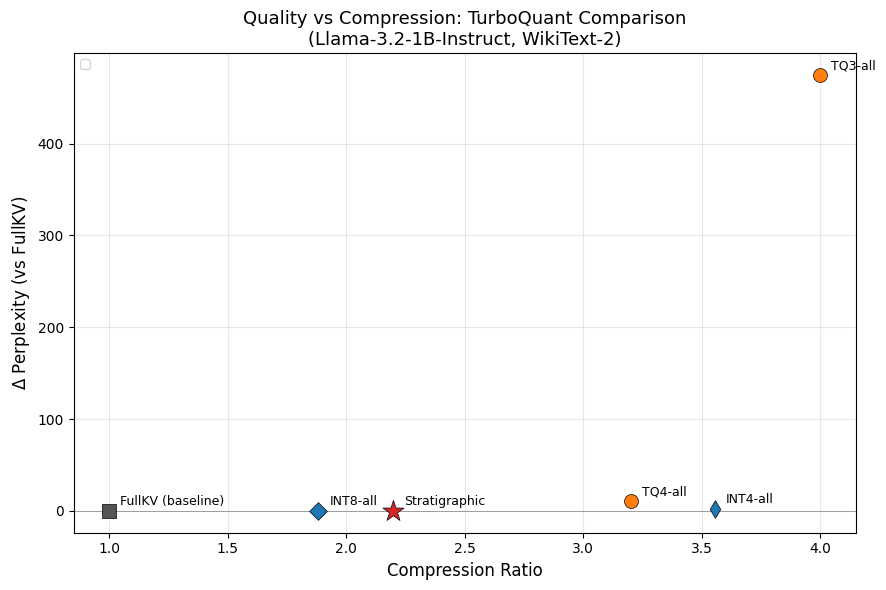

In [11]:
baseline_ppl = results[0].perplexity

# Style per strategy
style_map = {
    'FullKV (baseline)': {'c': '#555555', 'marker': 's', 'ms': 10, 'label': 'FullKV (baseline)'},
    'INT8-all':          {'c': '#1f77b4', 'marker': 'D', 'ms': 9,  'label': 'INT8-all'},
    'INT4-all':          {'c': '#1f77b4', 'marker': 'd', 'ms': 9,  'label': 'INT4-all'},
    'TQ3-all':           {'c': '#ff7f0e', 'marker': 'o', 'ms': 10, 'label': 'TQ3-all (3-bit)'},
    'TQ4-all':           {'c': '#ff7f0e', 'marker': 'o', 'ms': 10, 'label': 'TQ4-all (4-bit)'},
    'Stratigraphic':     {'c': '#d62728', 'marker': '*', 'ms': 16, 'label': 'Stratigraphic'},
}

fig, ax = plt.subplots(1, 1, figsize=(9, 6))

for r in results:
    delta = r.perplexity - baseline_ppl
    s = style_map.get(r.name, {'c': 'gray', 'marker': 'x', 'ms': 8, 'label': r.name})
    ax.scatter(r.compression_ratio, delta,
               c=s['c'], marker=s['marker'], s=s['ms']**2,
               zorder=5, edgecolors='black', linewidths=0.5)
    ax.annotate(r.name, (r.compression_ratio, delta),
                xytext=(8, 4), textcoords='offset points', fontsize=9)

# Pareto frontier: connect non-dominated points (lower delta + higher compression = better)
points = sorted([(r.compression_ratio, r.perplexity - baseline_ppl) for r in results])
pareto = [points[0]]
for p in points[1:]:
    if p[1] <= pareto[-1][1]:
        pareto.append(p)
if len(pareto) > 1:
    px, py = zip(*pareto)
    ax.plot(px, py, '--', color='#d62728', alpha=0.4, linewidth=1.5, label='Pareto frontier')

ax.set_xlabel('Compression Ratio', fontsize=12)
ax.set_ylabel(r'$\Delta$ Perplexity (vs FullKV)', fontsize=12)
ax.set_title(f'Quality vs Compression: TurboQuant Comparison\n({MODEL.split("/")[-1]}, WikiText-2)', fontsize=13)
ax.axhline(y=0, color='grey', linewidth=0.5, linestyle='-')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_path = Path('kv_bench/results/turboquant_pareto.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved to {save_path.resolve()}')
plt.show()

## Summary

In [12]:
# LaTeX table
print('% LaTeX table for report')
print(r'\begin{table}[h]')
print(r'\centering')
print(r'\caption{TurboQuant comparison on ' + MODEL.split('/')[-1] + r' (WikiText-2)}')
print(r'\label{tab:turboquant}')
print(r'\begin{tabular}{lcccc}')
print(r'\hline')
print(r'Strategy & Eff. Bits & PPL & $\Delta$PPL & Compression \\')
print(r'\hline')

bits_map = {
    'FullKV (baseline)': '16',
    'INT8-all': '8',
    'INT4-all': '4',
    'TQ3-all': '3',
    'TQ4-all': '4',
    'Stratigraphic': 'mixed',
}

for r in sorted(results, key=lambda r: r.compression_ratio):
    delta = r.perplexity - baseline_ppl
    delta_str = f'{delta:+.2f}' if abs(delta) > 0.005 else '---'
    bits = bits_map.get(r.name, '?')
    print(f'{r.name} & {bits} & {r.perplexity:.2f} & {delta_str} & {r.compression_ratio:.1f}$\\times$ \\\\')

print(r'\hline')
print(r'\end{tabular}')
print(r'\end{table}')

% LaTeX table for report
\begin{table}[h]
\centering
\caption{TurboQuant comparison on Llama-3.2-1B-Instruct (WikiText-2)}
\label{tab:turboquant}
\begin{tabular}{lcccc}
\hline
Strategy & Eff. Bits & PPL & $\Delta$PPL & Compression \\
\hline
FullKV (baseline) & 16 & 13.71 & --- & 1.0$\times$ \\
INT8-all & 8 & 13.72 & +0.01 & 1.9$\times$ \\
Stratigraphic & mixed & 13.88 & +0.16 & 2.2$\times$ \\
TQ4-all & 4 & 24.32 & +10.61 & 3.2$\times$ \\
INT4-all & 4 & 16.16 & +2.45 & 3.6$\times$ \\
TQ3-all & 3 & 488.40 & +474.69 & 4.0$\times$ \\
\hline
\end{tabular}
\end{table}


In [13]:
# Key findings
print('=== Key Findings ===\n')

# Find strategies by name
by_name = {r.name: r for r in results}

# TQ3 vs INT4
if 'TQ3-all' in by_name and 'INT4-all' in by_name:
    tq3 = by_name['TQ3-all']
    int4 = by_name['INT4-all']
    print(f'TQ3 (3-bit) vs INT4 (4-bit):')
    print(f'  TQ3:  PPL={tq3.perplexity:.2f}, compression={tq3.compression_ratio:.2f}x')
    print(f'  INT4: PPL={int4.perplexity:.2f}, compression={int4.compression_ratio:.2f}x')
    if tq3.perplexity < int4.perplexity:
        print(f'  --> TQ3 wins: better quality with higher compression')
    else:
        print(f'  --> INT4 wins on quality ({int4.perplexity:.2f} < {tq3.perplexity:.2f})')
    print()

# TQ4 vs INT8
if 'TQ4-all' in by_name and 'INT8-all' in by_name:
    tq4 = by_name['TQ4-all']
    int8 = by_name['INT8-all']
    print(f'TQ4 (4-bit) vs INT8 (8-bit):')
    print(f'  TQ4:  PPL={tq4.perplexity:.2f}, compression={tq4.compression_ratio:.2f}x')
    print(f'  INT8: PPL={int8.perplexity:.2f}, compression={int8.compression_ratio:.2f}x')
    print()

# Best Pareto point (highest compression with <0.5 delta PPL)
good = [r for r in results if (r.perplexity - baseline_ppl) < 0.5]
if good:
    best = max(good, key=lambda r: r.compression_ratio)
    print(f'Best strategy with <0.5 DPPL:')
    print(f'  {best.name}: PPL={best.perplexity:.2f} (delta={best.perplexity - baseline_ppl:+.2f}), '
          f'compression={best.compression_ratio:.2f}x')

=== Key Findings ===

TQ3 (3-bit) vs INT4 (4-bit):
  TQ3:  PPL=488.40, compression=4.00x
  INT4: PPL=16.16, compression=3.56x
  --> INT4 wins on quality (16.16 < 488.40)

TQ4 (4-bit) vs INT8 (8-bit):
  TQ4:  PPL=24.32, compression=3.20x
  INT8: PPL=13.72, compression=1.88x

Best strategy with <0.5 DPPL:
  Stratigraphic: PPL=13.88 (delta=+0.16), compression=2.20x
